In [1]:
# import necessary packages
import numpy as np
import pandas as pd
import re, importlib
from tqdm import tqdm
import os, sys, json
from itertools import product
from web_model import params, model  # Load parameters and model implementation.
from pathlib import Path
import time
import PBcombos as pbc
from collections import Counter
print(os.getcwd())
importlib.reload(model)
importlib.reload(pbc)
pd.options.display.float_format = "{:20,.4f}".format
print(pd.__version__)
print(np.__version__)

root_path = Path().parent

param_list = list(params.df_typing_formatting.T.to_dict().values())
model_params = {row["keys"]: row["values"] for row in param_list}
sm = model.SolveModel(model_params)
prod_change_dict = sm.prod_change_dict

/home/gustav/dev/pbtech
2.2.2
1.26.4


In [ ]:
def check(discrete_vals = [0,1], param_idx_restrict_vals=None, file_name_extension=''):
    """ Method for assessing outcome of policy combinatins"""
    good_for_all_pbs = []
    pb_improvement_cnts = {}
    pb_improvement_cnt_details = {}
    good_for_clim_biod_effects = []
    total =len(discrete_vals)**17
    import time
    st = time.time()
    combo_results = pbc.check_combos(discrete_vals, root_path / "results", batches=1, param_idx_restrict_vals=param_idx_restrict_vals, file_name_extension=file_name_extension)
    pbs = ['Aerosol effect','CO2 effect','Biodiv. incl. climate effect','Biogeochem. effect','Freshwater effect','Ocean acid. effect','Land-use effect']
    for c, pb_effects in tqdm(combo_results, total=total):
        sum_pb_effects = sum(pb_effects)
        assert not 2 in c
        if sum_pb_effects in pb_improvement_cnts:
            pb_improvement_cnts[sum_pb_effects] += 1 
            for ii, pb in enumerate(pbs):
                pb_improvement_cnt_details[sum_pb_effects][pb] += int(pb_effects[ii])
        else:
            pb_improvement_cnts[sum_pb_effects] = 1
            pb_improvement_cnt_details[sum_pb_effects] = dict(list(zip(pbs, [int(pe) for pe in pb_effects])))

        if pb_effects[1] and pb_effects[2]:
            good_for_clim_biod_effects.append(c)

        if all(pb_effects):
            good_for_all_pbs.append(c)
    print(time.time()-st)
    return good_for_all_pbs, good_for_clim_biod_effects, dict(sorted(pb_improvement_cnts.items())), dict(sorted(pb_improvement_cnt_details.items()))

## O, 1 percents runs

In [19]:

param_idx_restrict_vals = {4: 0, 7: 0, 12: 0, 14: 0, 16: 0}
good_for_all_pbs_0_1, good_for_clim_biod_effects_0_1, pb_improvement_cnts_0_1, pb_improvement_cnt_details_0_1 = check(discrete_vals = [0,1], param_idx_restrict_vals=param_idx_restrict_vals, file_name_extension="_restrict_4096")
#good_for_all_pbs_0_1, good_for_clim_biod_effects_0_1, pb_improvement_cnts_0_1, pb_improvement_cnt_details_0_1 = check()

  0%|          | 0/131072 [00:00<?, ?it/s]

loading: pb_0_combos_0_1_restrict_4096.npy


  3%|▎         | 4096/131072 [00:00<00:02, 56800.65it/s]

0.07401013374328613


In [32]:
pb_improvement_cnts_0_1
good_for_all_pbs_0_1
pb_improvement_cnts_0_1

{0: 5, 1: 85, 2: 265, 3: 247, 4: 860, 5: 2184, 6: 449, 7: 1}

([<matplotlib.axis.YTick at 0x7f5822637620>,
 [Text(0, 0.0, '0'),
  Text(0, 2.0, '2'),
  Text(0, 4.0, '4'),
  Text(0, 6.0, '6'),
  Text(0, 8.0, '8'),
  Text(0, 10.0, '10'),
  Text(0, 12.0, '12'),
  Text(0, 14.0, '14'),
  Text(0, 16.0, '16'),
  Text(0, 18.0, '18'),
  Text(0, 20.0, '20'),
  Text(0, 22.0, '22')])

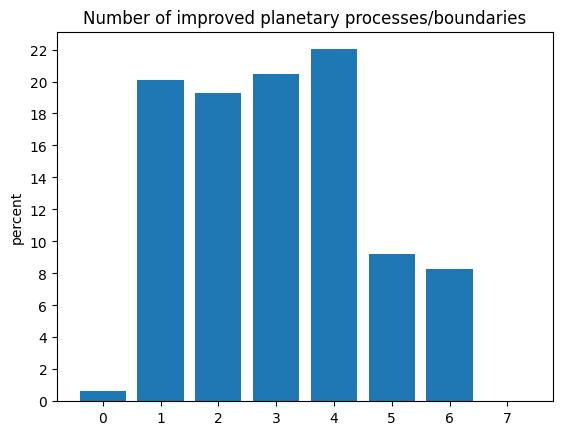

In [34]:
import matplotlib.pyplot as plt
fix, ax = plt.subplots()
ax.set_ylabel("percent")
ax.set_title("Number of improved planetary processes/boundaries")

norm_pb_improvement_cnts_0_1 = {k: 100*v/sum(pb_improvement_cnts.values()) for k, v in pb_improvement_cnts.items()}
plt.bar(pb_improvement_cnts_0_1.keys(), norm_pb_improvement_cnts_0_1.values())
plt.yticks(np.arange(0, max(norm_pb_improvement_cnts_0_1.values()), 2))

## O, 1 and 2 percents

In [26]:
discrete_vals = [0,1,2]

discrete_vals_str = [str(d) for d in discrete_vals]
var_file = root_path / "results" / f"pb_combos_vars_{'_'.join(discrete_vals_str)}.txt"
with open(var_file, "r") as f:
    pbs = json.loads(f.read())

pbs

['Aerosol effect',
 'CO2 effect',
 'Biodiv. incl. climate effect',
 'Biogeochem. effect',
 'Freshwater effect',
 'Ocean acid. effect',
 'Land-use effect']

In [27]:
good_for_all_pbs = []
discrete_vals = [0,1,2]
pb_improvement_cnts = {}    # Out of all the combinations how many improve exactly 1,2,3,4,5,6 boundaries
pb_improvement_cnt_details = {}   # Out of all the combinations that improve exactly 1,2,3,4,5,6 boundaries which one is the most unlikely to improve 
good_for_clim_biod_effects = []
total =len(discrete_vals)**17
import time
st = time.time()
combo_results = pbc.check_combos(discrete_vals, root_path / "results")
pbs = ['Aerosol effect','CO2 effect','Biodiv. incl. climate effect','Biogeochem. effect','Freshwater effect','Ocean acid. effect','Land-use effect']

for c, pb_effects in tqdm(combo_results, total=total):
    sum_pb_effects = sum(pb_effects)
    if sum_pb_effects in pb_improvement_cnts:
        pb_improvement_cnts[sum_pb_effects] += 1 
        for ii, pb in enumerate(pbs):
            pb_improvement_cnt_details[sum_pb_effects][pb] += int(pb_effects[ii])
    else:
        pb_improvement_cnts[sum_pb_effects] = 1
        pb_improvement_cnt_details[sum_pb_effects] = dict(list(zip(pbs, [int(pe) for pe in pb_effects])))

    if pb_effects[1] and pb_effects[2]:
        good_for_clim_biod_effects.append(c)

    if all(pb_effects):
        good_for_all_pbs.append(c)
print(time.time()-st)


  0%|          | 0/129140163 [00:00<?, ?it/s]

loading: pb_0_combos_0_1_2.npy


 10%|▉         | 12914016/129140163 [00:58<08:43, 221963.72it/s]


loading: pb_1_combos_0_1_2.npy


 10%|▉         | 12914016/129140163 [00:58<08:47, 220319.86it/s]


...

loading: pb_9_combos_0_1_2.npy


 10%|▉         | 12914016/129140163 [00:58<08:43, 221821.11it/s]]


loading: pb_10_combos_0_1_2.npy


100%|██████████| 129140163/129140163 [09:55<00:00, 217007.61it/s]

595.0968403816223


In [30]:
pb_improvement_cnts

{0: 791795,
 3: 25990715,
 4: 24934512,
 2: 26428897,
 5: 28432686,
 1: 11883940,
 6: 10677580,
 7: 38}

In [36]:
print(pb_improvement_cnts[6])
pb_improvement_cnt_details[6]

10677580


{'Aerosol effect': 10677580,
 'CO2 effect': 10677580,
 'Biodiv. incl. climate effect': 140,
 'Biogeochem. effect': 10677580,
 'Freshwater effect': 10677501,
 'Ocean acid. effect': 10677580,
 'Land-use effect': 10677519}

In [25]:
tcb=4096 #2**17
pb_improvement_cnts = pb_improvement_cnts_0_1
pb_improvement_cnt_details = pb_improvement_cnt_details_0_1
pb_improvement_cnts = dict(sorted(pb_improvement_cnts.items()))
for ii, (pbsolved, pbcnt) in enumerate(pb_improvement_cnts.items()):
    #print(ii, round(100*pbcnt/tcb, 3), pb_improvement_cnt_details[ii])
    climate_improv = round(100*pb_improvement_cnt_details[ii]['CO2 effect']/pbcnt, 2)
    biodiv_improv = round(100*pb_improvement_cnt_details[ii]['Biodiv. incl. climate effect']/pbcnt, 5)
    print(f"{round(pbcnt*100/tcb,1)}%")
    #print(f"({climate_improv}% / {biodiv_improv}%)")
    #print('---')

0.1%
2.1%
6.5%
6.0%
21.0%
53.3%
11.0%
0.0%


In [15]:


tech_changes = list(prod_change_dict.keys())
df = pd.DataFrame(index=tech_changes, columns=["0%", "1%", "2%"])
good_combos = {k: [] for k in tech_changes}
cnt= 0
for gc in good_for_all_pbs:
    for ii, k in enumerate(tech_changes):
        good_combos[k].append(gc[ii])


for k in tech_changes:
    good_combos[k] = dict(Counter(good_combos[k]))
    df.loc[k, "0%"] = good_combos[k].get(0, 0)
    df.loc[k, "1%"] = good_combos[k].get(1, 0)
    df.loc[k, "2%"] = good_combos[k].get(2, 0)

print('cnt',cnt)
good_combos

df.to_csv(root_path / "results" / 'good_for_all_pbs.csv')

cnt 0


In [23]:
sum_good_for_clim_biod_effects
total=sum(pb_improvement_cnts.values())
pb_improvement_list = sorted(pb_improvement_cnts.items(), key=lambda x: x[0])
pb_improvement_list = [(pbi[0], round(100*pbi[1]/total,6)) for pbi in pb_improvement_list]
for pbi in pb_improvement_list:
    print(pbi[0], str(pbi[1]) + "%")

0 0.613128%
1 9.202358%
2 20.465281%
3 20.125974%
4 19.3081%
5 22.01692%
6 8.26821%
7 2.9e-05%


## -1, O,  and 1 percents

In [20]:
def check(discrete_vals, batches=1):

    good_for_all_pbs = []
    pb_improvement_cnts = {}
    good_for_clim_biod_effects = []
    total =len(discrete_vals)**17
    import time
    st = time.time()
    combo_results = pbc.check_combos(discrete_vals, root_path / "results", batches=batches)
    for c, pb_effects in tqdm(combo_results, total=total):
        sum_pb_effects = sum(pb_effects)
        if sum_pb_effects in pb_improvement_cnts:
            pb_improvement_cnts[sum_pb_effects] += 1 
        else:
            pb_improvement_cnts[sum_pb_effects] = 1

        if pb_effects[1] and pb_effects[2]:
            good_for_clim_biod_effects.append(c)

        if all(pb_effects):
            good_for_all_pbs.append(c)
    print(time.time()-st)
    return good_for_all_pbs, good_for_clim_biod_effects

discrete_vals = [-1,0,1]
good_for_all_pbs__1_0_1, good_for_clim_biod_effects__1_0_1 = check(discrete_vals, batches=10)

  0%|          | 0/129140163 [00:00<?, ?it/s]

loading: pb_0_combos_-1_0_1.npy


 10%|▉         | 12914016/129140163 [00:35<05:15, 368684.12it/s]


loading: pb_1_combos_-1_0_1.npy


 10%|▉         | 12914016/129140163 [00:34<05:14, 369049.51it/s]


...

loading: pb_9_combos_-1_0_1.npy


 10%|▉         | 12914016/129140163 [00:35<05:16, 367562.17it/s]]


loading: pb_10_combos_-1_0_1.npy


100%|██████████| 129140163/129140163 [06:12<00:00, 347002.90it/s]

372.1601872444153


In [27]:
print(len(good_for_all_pbs__1_0_1)/129140163) 
print(len(good_for_clim_biod_effects__1_0_1)/129140163) 

0.03762235455750509
0.32296540465106893


## Check specific combo

In [72]:
def pb_boundary(c, pack=True):
    dfnp = np.array([[0.0010672170921913766, 0.041064083724359594, 0.03606265998995495, -0.09056933011478599, -0.04212802843617142, 0.041064083724359594, -0.009457889673203462, 1.0, 0.0], [0.000280677776028135, 0.008976494788867724, 0.01177139088129886, 0.03526377679207529, 0.01852054800088953, 0.008976494788867724, 0.02102473117337316, 1.0, 0.0], [0.00020340503955239205, 0.006589680358849447, -0.006776759136928323, -0.7402134722784179, 0.022800158842504303, 0.006589680358849447, 0.026026952518861418, 1.0, 0.0], [9.9185328694472e-05, 0.003172095057746263, 0.00415974962560961, 0.012461440095563102, -0.3842849415925758, 0.003172095057746263, 0.0074296757714614955, 1.0, 0.0], [0.003884525919690355, 0.12423294486923242, 0.1629137640898226, 0.48804382346702246, 0.2563207881093982, 0.12423294486923242, 0.290978196967412, 1.0, 0.0], [-0.00024021385317936803, -0.007525790597789012, 0.0038170542693505283, -0.7438123683284646, 0.0015344277486948853, -0.007525790597789012, 0.0020087592144643757, 1.0, -1.0], [0.00014337353262626137, 0.004561989962317463, 0.015669995737233045, -0.47658456002351374, 0.006872888059443555, 0.004561989962317463, 0.007762458447490711, 1.0, 0.0], [0.0003002453601054886, 0.009553480994320743, 0.03281528624420327, 0.48018345607356033, 0.014392843034365638, 0.009553480994320743, 0.01625573485690654, 1.0, 0.0], [-0.0006111707649527577, -0.01246899195121234, -0.002054702421672161, 0.025601994295128286, 0.009820830412398384, -0.01246899195121234, -0.0347027538961542, -1.0, -1.0], [-0.010601937582399506, -0.18222918227136342, 0.006492022805304476, 0.030006844126706043, -0.01827941758527299, -0.18222918227136342, 0.02399593109999751, 0.0, -1.0], [-0.001378795905645309, -0.02429506543859241, 0.001620392870027576, 0.006529822849102153, -0.0011754369121571736, -0.02429506543859241, 0.0016281928468621894, 0.0, -1.0], [-0.011353948105761754, -0.19686385686103025, 0.005973005270065723, 0.05761786114221153, -0.007917923440818157, -0.19686385686103025, -0.011396641580090863, 0.0, -1.0], [0.007955944854472449, 0.2614958180324138, 0.10111898011515574, 0.28702815750204236, 0.16405574909673404, 0.2614958180324138, -0.6538286204894805, 1.0, 0.0], [-4.432538898446151e-05, -0.001712370567540188, 0.007170572698467215, -0.0027423063067561065, -0.0014945870566598976, -0.001712370567540188, 0.0026320395286490873, 0.0, -1.0], [0.00019221806859163147, 0.0017392470741345537, 0.04032729896277232, -0.018034945822891793, -0.00826967604066459, 0.0017392470741345537, 0.014594754586366124, 1.0, -1.0], [1.0008546572808551e-05, -0.0008635002555022078, 0.059912845007070725, -0.0014463897522506383, -0.0005926498932396549, -0.0008635002555022078, 0.013885795678424254, 1.0, 0.0], [0.00013047951009683057, 0.0035842060759157883, 0.15737326705952404, -0.001374217876452746, -0.00039992010625888993, 0.0035842060759157883, -0.01968233909427637, 1.0, -1.0]])
    dc = dfnp * np.array(c).reshape(len(c), 1)
    dc_sum = dc.sum(axis=0)[0:7]<=0
    return dc_sum

In [92]:
tech_params = {
        ("A_LA", "Land use efficiency in agriculture"): 0,
        ("A_EpsA", "Energy efficiency agriculture"): 1,
        ("A_P", "Fertilizer efficiency in agriculture"): 1,
        ("A_W", "Water efficiency in agriculture"): 1,
        ("A_MA", "Other inputs efficiency in agriculture"): 0,
        ("P_EP", "Fossil fuel efficiency in fertilizer prod."): 1,
        ("P_Pho", "Phosphor efficiency in fertilizer prod."): 1,
        ("P_MP", "Other inputs efficiency in fertilizer prod."): 0,
        ("Eps_AB", "Biofuel efficiency in energy service prod."): 1,
        ("Eps_EEps", "Fossil fuel efficiency in energy service prod."): 1,
        ("Eps_R", "Renewable efficiency in energy service prod."): 1,
        ("Y_EpsY", "Energy services efficiency in manufacturing"): 1,
        ("Y_MY", "Other inputs efficiency in manufacturing"): 0,
        ("Fi_EFi", "Fossil fuels efficiency in fisheries"): 1,
        ("Fi_MFi", "Other inputs efficiency in fisheries"): 0,
        ("T_LT", "Land use efficiency in timber prod."): 1,
        ("T_MT", "Other inputs efficiency in timber prod."): 0,
    }
#tech_params = {k: int(v==0) for k,v in tech_params.items()}
results=pb_boundary(list(tech_params.values()), pack=False)
pbs = {'Aerosol effect': None,
 'CO2 effect': None,
 'Biodiv. incl. climate effect': None,
 'Biogeochem. effect': None,
 'Freshwater effect': None,
 'Ocean acid. effect': None,
 'Land-use effect': None
 }
{pb: results[ii] for ii, (pb, _) in enumerate(pbs.items())}

{'Aerosol effect': True,
 'CO2 effect': True,
 'Biodiv. incl. climate effect': False,
 'Biogeochem. effect': True,
 'Freshwater effect': True,
 'Ocean acid. effect': True,
 'Land-use effect': False}

# Latte

In [13]:
# Generate result and feasible param space for a specific combination of tech params and boundaries

import warnings, importlib
warnings.simplefilter(action='ignore', category=FutureWarning)
import PBcombos as pbc
importlib.reload(pbc)

tech_params = {
    ("A_LA", "Land use efficiency in agriculture"): 1,
    ("A_EpsA", "Energy efficiency agriculture"): 1,
    ("A_P", "Fertilizer efficiency in agriculture"): 1,
    ("A_W", "Water efficiency in agriculture"): 1,
    ("A_MA", "Other inputs efficiency in agriculture"): 1,
    ("P_EP", "Fossil fuel efficiency in fertilizer prod."): 1,
    ("P_Pho", "Phosphor efficiency in fertilizer prod."): 1,
    ("P_MP", "Other inputs efficiency in fertilizer prod."): 1,
    ("Eps_AB", "Biofuel efficiency in energy service prod."): 1,
    ("Eps_EEps", "Fossil fuel efficiency in energy service prod."): 1,
    ("Eps_R", "Renewable efficiency in energy service prod."): 1,
    ("Y_EpsY", "Energy services efficiency in manufacturing"): 1,
    ("Y_MY", "Other inputs efficiency in manufacturing"): 1,
    ("Fi_EFi", "Fossil fuels efficiency in fisheries"): 1,
    ("Fi_MFi", "Other inputs efficiency in fisheries"): 1,
    ("T_LT", "Land use efficiency in timber prod."): 1,
    ("T_MT", "Other inputs efficiency in timber prod."): 1,
}
boundaries = {'Aerosol effect': 0,
 'CO2 effect': 0,
 'Biodiv. incl. climate effect': 0,
 'Biogeochem. effect': 0,
 'Freshwater effect': 0,
 #'Ocean acid. effect': 1,
 'Land-use effect': 0,
 'Food price effect': 1,
 'Food quantity effect': 1
}

#pbc.gen_hrep_file_new(tech_params, boundaries, dir="/home/gustav/dev/pbtech/results/combo_latte_gt/", exclude_non_active_boundaries=True)
result, tech_param_range, barycenter_params = pbc.gen_latte(tech_params, boundaries, constraints=[0,1], compute_vertices=False, compute_polyhedra_volume=True, compute_vertex_barycenter=False, exclude_non_active_boundaries=True, selected_columns=[0,1,2,3,4,5,6,9])

# 7.506175251765734e-20
# 1.426820636564419e-19
#result
#nL: 0.21074829666400763
#wL: 0.21074829666400763

 
###### Running latte ##########
included_boundaries:  ['Aerosol effect', 'CO2 effect', 'Biodiv. incl. climate effect', 'Biogeochem. effect', 'Freshwater effect', 'Land-use effect', 'Food price effect', 'Food quantity effect']
Hrep file generated
Compute polyhedra


In [12]:
result

2.631722264711191e-19

In [7]:
# CALCULATE VERTEX BARYCENTER USING POLYMAKE

import JuPyMake
JuPyMake.InitializePolymake()
## POLYMAKE Convert to Vertic representation ##
with open("/home/gustav/dev/pbtech/latte/pbtech/pb.hrep.latte", "r") as f:
    hrep_content = f.readlines()
ineqs = ",".join(
    [
        "[{}]".format(row.replace("\n", "").replace(" ", ","))
        for row in hrep_content[1:]
    ]
)
print(ineqs)
p = f"$p = new Polytope(INEQUALITIES=>[{ineqs}]);"
JuPyMake.ExecuteCommand(p)
vrep_barycenter = JuPyMake.ExecuteCommand("print $p->VERTEX_BARYCENTER;")
bcenter = []
tps = [k for k, v in tech_param_range.items() if v is not None]
for idx, v in enumerate(vrep_barycenter[1].split()):
    if idx == 0:
        continue
    tp = tps[idx-1]
    print(f"{idx} ({tp}): ", eval(v))
    if tech_param_range[tp] and len(tech_param_range[tp])==2:
        tech_param_range[tp].append(eval(v))

    bcenter.append(eval(v))


# with open(f"/home/gustav/dev/pbtech/figures/data/tech_factor_space_green_tech.json", "w") as f:
#     f.write(json.dumps(tech_param_range))

[0,-107,-28,-20,-10,-388,24,-14,-30,61,1060,138,1135,-796,4,-19,-1,-13],[0,-4106,-898,-659,-317,-12423,753,-456,-955,1247,18223,2430,19686,-26150,171,-174,86,-358],[0,-361,-118,68,-42,-1629,-38,-157,-328,21,-65,-16,-60,-1011,-72,-403,-599,-1574],[0,906,-353,7402,-125,-4880,7438,4766,-4802,-256,-300,-65,-576,-2870,27,180,14,14],[0,4213,-1852,-2280,38428,-25632,-153,-687,-1439,-982,1828,118,792,-16406,149,827,59,40],[0,-95,210,260,74,2910,20,78,163,-347,240,16,-114,-6538,26,146,139,-197],[1,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],[0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],[1,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],[0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],[1,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],[0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],[1,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0],[0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],[1,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],[1,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],[1,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0],[0,0,0,0

In [ ]:
importlib.reload(pbc)
dft = pbc.compute_pb_tech_individual()
#dft.to_csv('tech_change.csv')

In [ ]:

dft = pbc.compute_pb_tech_individual()[:,0]*1e12
vec = []
for idx, (k, par) in enumerate( tech_params.items()):
    if par==0:
        continue
    vec.append(dft[idx])
    func = lambda x0,x1,x2: max(min((-k[0]*x0-k[1]*x1-k[2]*x2)/k[3],1), 0)
    

In [3]:
from scipy import integrate

k = [-99185329, -3884525920, 240213853, 611170765]
func = lambda x0,x1,x2: max(min((-k[0]*x0-k[1]*x1-k[2]*x2)/k[3],1), 0)
res, _ = integrate.nquad(func, [[0,1], [0,1], [0,1]])
1-res

/home/gustav/anaconda3/envs/py312/lib/python3.12/site-packages/scipy/integrate/_quadpack_py.py:1272: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


0.09689125086042027

Parameter definitions: $A_{L_A}$ (land use efficiency in agriculture), $A_{\mathcal{E}_A}$ (energy efficiency agriculture), $A_P$ (fertilizer efficiency in agriculture), $A_W$ (water efficiency in agriculture), $A_{M_A}$ (other inputs efficiency in agriculture), $P_{E_P}$ (fossil fuel efficiency in fertilizer prod.), $P_{\mathcal{P}}$ (phosphor efficiency in fertilizer prod.), $P_{M_P}$ (other inputs efficiency in fertilizer prod.), $\mathcal{E}_{A_B}$ (biofuel efficiency in energy service prod.), $\mathcal{E}_{E_{\mathcal{E}}}$ (fossil fuel efficiency in energy service prod.), $\mathcal{E}_R$ (renewable efficiency in energy service prod.), $Y_{\mathcal{E}_Y}$ (energy services efficiency in manufacturing), $Y_{M_Y}$ (other inputs efficiency in manufacturing), $F_{E_F}$ (fossil fuels efficiency in fisheries), $F_{M_F}$ (other inputs efficiency in fisheries), $T_{L_T}$ (land use efficiency in timber prod.), $T_{M_T}$ (other inputs efficiency in timber prod.), 
Expected value of PB
Aeroso

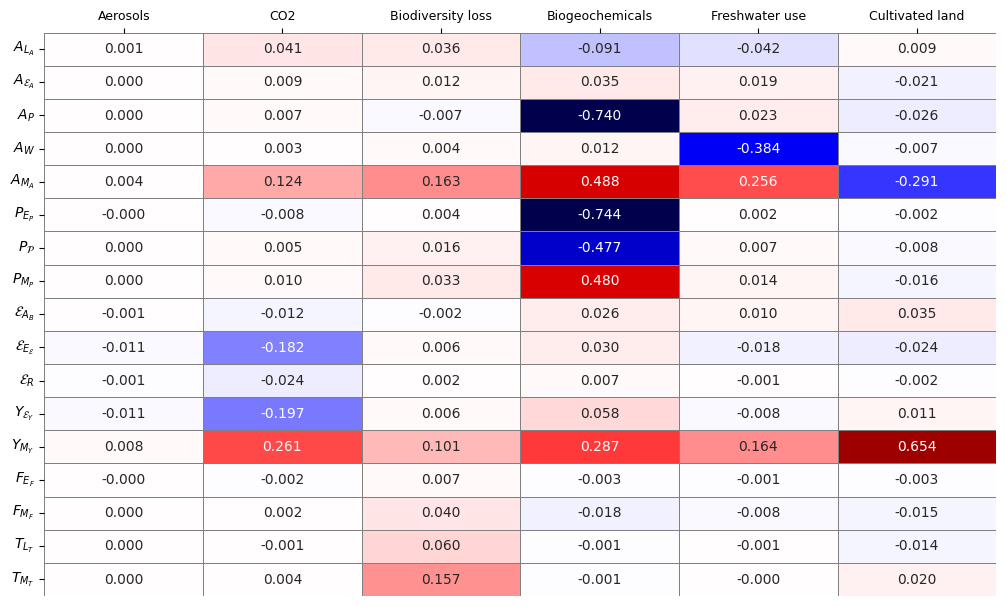

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load CSV
csv_file = "tech_change.csv"  # Update this path
df = pd.read_csv(csv_file, index_col=0).iloc[:,[0,1,2,3,4,6]]

df.loc[:, 'Land-use effect'] = df.loc[:, 'Land-use effect']*-1

# Dictionary mapping row labels to LaTeX and descriptions
row_labels_map = {'A_LA': ("$A_{L_A}$", "(land use efficiency in agriculture)"),
 'A_EpsA': ("$A_{\\mathcal{E}_A}$", "(energy efficiency agriculture)"),
 'A_P': ("$A_P$", "(fertilizer efficiency in agriculture)"),
 'A_W': ("$A_W$", "(water efficiency in agriculture)"),
 'A_MA': ("$A_{M_A}$", "(other inputs efficiency in agriculture)"),
 'P_EP': ("$P_{E_P}$", "(fossil fuel efficiency in fertilizer prod.)"),
 'P_Pho': ("$P_{\\mathcal{P}}$", "(phosphor efficiency in fertilizer prod.)"),
 'P_MP': ("$P_{M_P}$", "(other inputs efficiency in fertilizer prod.)"),
 'Eps_AB': ("$\\mathcal{E}_{A_B}$", "(biofuel efficiency in energy service prod.)"),  
 'Eps_EEps': ("$\\mathcal{E}_{E_{\\mathcal{E}}}$", "(fossil fuel efficiency in energy service prod.)"),
 'Eps_R': ("$\\mathcal{E}_R$", "(renewable efficiency in energy service prod.)"),
 'Y_EpsY': ("$Y_{\\mathcal{E}_Y}$", "(energy services efficiency in manufacturing)"),
 'Y_MY': ("$Y_{M_Y}$", "(other inputs efficiency in manufacturing)"),
 'Fi_EFi': ("$F_{E_F}$", "(fossil fuels efficiency in fisheries)"),
 'Fi_MFi': ("$F_{M_F}$", "(other inputs efficiency in fisheries)"),
 'T_LT': ("$T_{L_T}$", "(land use efficiency in timber prod.)"),
 'T_MT': ("$T_{M_T}$", "(other inputs efficiency in timber prod.)")
}
col_labels_map = {'Aerosol effect': "Aerosols",
 'CO2 effect': "CO2",
 'Biodiv. incl. climate effect': "Biodiversity loss",
 'Biogeochem. effect': "Biogeochemicals",
 'Freshwater effect': "Freshwater use",
 'Ocean acid. effect': "Ocean acidification",
 'Land-use effect': "Cultivated land"}

# Create caption text explaining parameters but don't add it to figure
caption = "Parameter definitions: "
for latex, desc in row_labels_map.values():
    caption += f"{latex} {desc}, "
print(caption)

# Separate labels
row_labels = [row_labels_map[var][0] for var in df.index.tolist()]
col_labels = [col_labels_map[var] for var in df.columns.tolist()]
df.columns = col_labels

# Convert values to float if needed
data = df.astype(float).values

print("Expected value of PB")
print(df.sum(axis=0)/2)


# Plot
plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    data,
    cmap="seismic",
    center=0,
    xticklabels=col_labels,
    yticklabels=row_labels,
    annot=True,          # Optional: show numbers
    fmt=".3f",           # Format for annotations
    linewidths=0.5,      # Gridlines
    linecolor='gray',
    cbar=False
)

# LaTeX formatting
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(rotation=0, ha='center', fontsize=9)
plt.yticks(rotation=0)

# Optional: enable LaTeX rendering
# plt.rcParams['text.usetex'] = True  # Uncomment if using LaTeX for full rendering
#plt.title("Heatmap of Matrix Values", fontsize=16)
plt.subplots_adjust(top=0.95, bottom=0.05)
plt.tight_layout(pad=0.5)
#plt.colorbar(ax.collections[0], label="Value")
plt.savefig("matrix_heatmap.pdf", dpi=300)
plt.show()

In [6]:
print("Cov Variance of PB")
import numpy as np
# Create covariance matrix
dfCov = df.T.dot(df)/12

# Create mean column
mean_values = df.sum(axis=0)/2

# Create MultiIndex columns
cov_columns = dfCov.columns
columns = pd.MultiIndex.from_tuples([('Mean', '')] + 
                                   [('Variance/covariance', col) for col in cov_columns])

# Create new dataframe with MultiIndex
dfCov_multi = pd.DataFrame(np.column_stack([mean_values, dfCov]), 
                          index=dfCov.index,
                          columns=columns)

dfCov_multi.style.format(precision=5)  #.to_excel("covariance.xlsx")


Cov Variance of PB


In [160]:
# Two boundary / two param integration 
import numpy as np
from scipy import integrate
# 0 991853 -2402139 -106019376
# 0 31720951 -75257906 -1822291823

boundaries = np.array([[-9919, 24021], [-317210, 752579]])
boundaries = np.array([[-991853, -38845259, 2402139], [-31720951, -1242329449, 75257906]])

boundaries = np.array([[1, 1, -2], ])
boundaries = np.array([[-991853, 2402139, 106019376], [-31720951, 75257906, 1822291823]])
#boundaries = np.array([[1, -2], [-2, 1] ])  # [1, -2], [-2, 1],
max_res, min_res = [], []
for boundary in boundaries:
    if boundary[-1] > 0:
        max_res.append(boundary)
    else:
        min_res.append(boundary)
        
def integral2d(x0):
    kp = [1]
    for boundary in max_res:
        k = np.array(boundary[:-1])
        ksum = -k.dot(x0)/boundary[-1]
        kp.append(ksum[0])
    max_val = np.min(kp)
    
    kp = [0]
    for boundary in min_res:
        k = np.array(boundary[:-1])
        ksum = -k.dot(x0)/boundary[-1]
        kp.append(ksum[0])
    min_val = np.max(kp)
    return max(max_val-min_val, 0)

def integral3d(x0, x1):
    kp = [1]
    for boundary in max_res:
        k = np.array(boundary[:-1])
        ksum = -(k[0]*x0 + k[1]*x1)/boundary[-1]
        kp.append(ksum)
    max_val = np.min(kp)
    
    kp = [0]
    for boundary in min_res:
        k = np.array(boundary[:-1])
        ksum = -(k[0]*x0 + k[1]*x1)/boundary[-1]
        kp.append(ksum)
    min_val = np.max(kp)
    return max(max_val-min_val, 0)

res, _ = integrate.nquad(integral3d, [[0,1], [0,1]])

#k=boundaries
#func = lambda x0: max(min(-k[1,0]*x0/k[1,1], 1) - max(-k[0,0]*x0/k[0,1], 0), 0)
#res, _ = integrate.nquad(func, [[0,1]])
res


0.0006438134116452726

In [4]:
df.T.dot(df)

,Aerosols,CO2,Biodiversity loss,Biogeochemicals,Freshwater use,Cultivated land
Aerosols,0.000323,0.006826,0.001380,0.003197,0.002510,0.004170
CO2,0.006826,0.158531,0.046790,0.118139,0.077051,0.136451
Biodiversity loss,0.001380,0.046790,0.069723,0.115647,0.055248,0.019783
Biogeochemicals,0.003197,0.118139,0.115647,1.894310,0.156875,0.061698
Freshwater use,0.002510,0.077051,0.055248,0.156875,0.243750,0.034680
Cultivated land,0.004170,0.136451,0.019783,0.061698,0.034680,0.516466


In [85]:
boundary.dot(boundary)
boundary.dot(boundary)


666997335341

In [33]:
min_res

[array([-9919, 24021]), array([-317210,  752579])]

In [29]:
# Two boundary / three param integration 
import numpy as np
k = np.array([[-9919, -388453, 24021], [-317210, -12423294, 752579]])
func = lambda x0, x1: max(min( (-k[0,0]*x0-k[0,1]*x1)/k[0,2], (-k[1,0]*x0-k[1,1]*x1)/k[1,2], 1), 0)
res, _ = integrate.nquad(func, [[0,1], [0,1]])
1-res


0.019908824642106304

In [42]:
from itertools import product
coords = list(product(range(7), repeat=2))
results = np.empty((7,7))
for c in coords:
    if c[0]==c[1]:
        continue
    active_boundaries = np.zeros(7)
    active_boundaries[c[0]] = 1
    active_boundaries[c[1]] = 1
    print(c, active_boundaries)
    b = dict(zip(list(boundaries.keys()), active_boundaries))
    result, _ = pbc.gen_latte(tech_params, b, constraints=[0,1])
    results[c] = result
    
#for boundaries
#    result, tech_param_range = pbc.gen_latte(tech_params, boundaries, constraints=[0,1])

(0, 1) [1. 1. 0. 0. 0. 0. 0.]
(0, 2) [1. 0. 1. 0. 0. 0. 0.]
(0, 3) [1. 0. 0. 1. 0. 0. 0.]
(0, 4) [1. 0. 0. 0. 1. 0. 0.]
(0, 5) [1. 0. 0. 0. 0. 1. 0.]
(0, 6) [1. 0. 0. 0. 0. 0. 1.]
(1, 0) [1. 1. 0. 0. 0. 0. 0.]
(1, 2) [0. 1. 1. 0. 0. 0. 0.]
(1, 3) [0. 1. 0. 1. 0. 0. 0.]
(1, 4) [0. 1. 0. 0. 1. 0. 0.]
(1, 5) [0. 1. 0. 0. 0. 1. 0.]
(1, 6) [0. 1. 0. 0. 0. 0. 1.]
(2, 0) [1. 0. 1. 0. 0. 0. 0.]
(2, 1) [0. 1. 1. 0. 0. 0. 0.]
(2, 3) [0. 0. 1. 1. 0. 0. 0.]
(2, 4) [0. 0. 1. 0. 1. 0. 0.]
(2, 5) [0. 0. 1. 0. 0. 1. 0.]
(2, 6) [0. 0. 1. 0. 0. 0. 1.]
(3, 0) [1. 0. 0. 1. 0. 0. 0.]
(3, 1) [0. 1. 0. 1. 0. 0. 0.]
(3, 2) [0. 0. 1. 1. 0. 0. 0.]
(3, 4) [0. 0. 0. 1. 1. 0. 0.]
(3, 5) [0. 0. 0. 1. 0. 1. 0.]
(3, 6) [0. 0. 0. 1. 0. 0. 1.]
(4, 0) [1. 0. 0. 0. 1. 0. 0.]
(4, 1) [0. 1. 0. 0. 1. 0. 0.]
(4, 2) [0. 0. 1. 0. 1. 0. 0.]
(4, 3) [0. 0. 0. 1. 1. 0. 0.]
(4, 5) [0. 0. 0. 0. 1. 1. 0.]
(4, 6) [0. 0. 0. 0. 1. 0. 1.]
(5, 0) [1. 0. 0. 0. 0. 1. 0.]
(5, 1) [0. 1. 0. 0. 0. 1. 0.]
(5, 2) [0. 0. 1. 0. 0. 1. 0.]
(5, 3) [0.

# Create feasible figures

In [21]:
import warnings, importlib
warnings.simplefilter(action='ignore', category=FutureWarning)
import PBcombos as pbc
importlib.reload(pbc)

tech_params = {
    ("A_LA", "Land use efficiency in agriculture"): 1,
    ("A_EpsA", "Energy efficiency agriculture"): 1,
    ("A_P", "Fertilizer efficiency in agriculture"): 1,
    ("A_W", "Water efficiency in agriculture"): 1,
    ("A_MA", "Other inputs efficiency in agriculture"): 1,
    ("P_EP", "Fossil fuel efficiency in fertilizer prod."): 1,
    ("P_Pho", "Phosphor efficiency in fertilizer prod."): 1,
    ("P_MP", "Other inputs efficiency in fertilizer prod."): 1,
    ("Eps_AB", "Biofuel efficiency in energy service prod."): 1,
    ("Eps_EEps", "Fossil fuel efficiency in energy service prod."): 1,
    ("Eps_R", "Renewable efficiency in energy service prod."): 1,
    ("Y_EpsY", "Energy services efficiency in manufacturing"): 1,
    ("Y_MY", "Other inputs efficiency in manufacturing"): 1,
    ("Fi_EFi", "Fossil fuels efficiency in fisheries"): 1,
    ("Fi_MFi", "Other inputs efficiency in fisheries"): 1,
    ("T_LT", "Land use efficiency in timber prod."): 1,
    ("T_MT", "Other inputs efficiency in timber prod."): 1,
}
boundaries = {'Aerosol effect': 0,
 'CO2 effect': 1,
 'Biodiv. incl. climate effect': 1,
 'Biogeochem. effect': 0,
 'Freshwater effect': 0,
 #'Ocean acid. effect': 1,
 'Land-use effect': 0
}

#pbc.gen_hrep_file_new(tech_params, boundaries, dir="/home/gustav/dev/pbtech/results/combo_latte_gt/", exclude_non_active_boundaries=True)
result, tech_param_range, barycenter_params = pbc.gen_latte(tech_params, boundaries, constraints=[0,1], compute_vertices=True, compute_polyhedra_volume=False, compute_vertex_barycenter=True, exclude_non_active_boundaries=True)

# CALCULATE VERTEX BARYCENTER USING POLYMAKE

import JuPyMake
JuPyMake.InitializePolymake()
## POLYMAKE Convert to Vertic representation ##
with open("/home/gustav/dev/pbtech/latte/pbtech/pb.hrep.latte", "r") as f:
    hrep_content = f.readlines()
ineqs = ",".join(
    [
        "[{}]".format(row.replace("\n", "").replace(" ", ","))
        for row in hrep_content[1:]
    ]
)

p = f"$p = new Polytope(INEQUALITIES=>[{ineqs}]);"
JuPyMake.ExecuteCommand(p)
vrep_barycenter = JuPyMake.ExecuteCommand("print $p->VERTEX_BARYCENTER;")
bcenter = []
tps = [k for k, v in tech_param_range.items() if v is not None]
for idx, v in enumerate(vrep_barycenter[1].split()):
    if idx == 0:
        continue
    tp = tps[idx-1]
    print(f"{idx} ({tp}): ", eval(v))
    if tech_param_range[tp] and len(tech_param_range[tp])==2:
        tech_param_range[tp].append(eval(v))
tech_param_range


 
###### Running latte ##########
Price change fish: $p_{F}$ $	ext{(fisheries)}$
Price change agri: $p_A$ $	ext{(agricultural goods)}$
Quant change agri: $A_F$ $	ext{(agriculture prod. for food)}$
Quant change fish: $F\;\;$ $	ext{(fisheries production)}$
Price change fish: $p_{F}$ $	ext{(fisheries)}$
Price change agri: $p_A$ $	ext{(agricultural goods)}$
Quant change agri: $A_F$ $	ext{(agriculture prod. for food)}$
Quant change fish: $F\;\;$ $	ext{(fisheries production)}$
Price change fish: $p_{F}$ $	ext{(fisheries)}$
Price change agri: $p_A$ $	ext{(agricultural goods)}$
Quant change agri: $A_F$ $	ext{(agriculture prod. for food)}$
Quant change fish: $F\;\;$ $	ext{(fisheries production)}$
Price change fish: $p_{F}$ $	ext{(fisheries)}$
Price change agri: $p_A$ $	ext{(agricultural goods)}$
Quant change agri: $A_F$ $	ext{(agriculture prod. for food)}$
Quant change fish: $F\;\;$ $	ext{(fisheries production)}$
Price change fish: $p_{F}$ $	ext{(fisheries)}$
Price change agri: $p_A$ $	ext{(agr

{('A_LA', 'Land use efficiency in agriculture'): [0.24307528104832227,
  0,
  0.009583881533413116],
 ('A_EpsA', 'Energy efficiency agriculture'): [0.7519828948497745,
  0,
  0.03447032791870427],
 ('A_P', 'Fertilizer efficiency in agriculture'): [1, 0, 0.9258693921463569],
 ('A_W', 'Water efficiency in agriculture'): [1, 0, 0.2891749856757503],
 ('A_MA', 'Other inputs efficiency in agriculture'): [0.05446885058435953,
  0,
  0.0024945329473042674],
 ('P_EP', 'Fossil fuel efficiency in fertilizer prod.'): [1,
  0,
  0.2583711881723317],
 ('P_Pho', 'Phosphor efficiency in fertilizer prod.'): [0.5668789808917197,
  0,
  0.015854003815861203],
 ('P_MP', 'Other inputs efficiency in fertilizer prod.'): [0.27134146341463417,
  0,
  0.00759071302699769],
 ('Eps_AB', 'Biofuel efficiency in energy service prod.'): [1,
  0,
  0.5696991576968565],
 ('Eps_EEps', 'Fossil fuel efficiency in energy service prod.'): [1,
  0,
  0.09685063206174299],
 ('Eps_R', 'Renewable efficiency in energy service pr

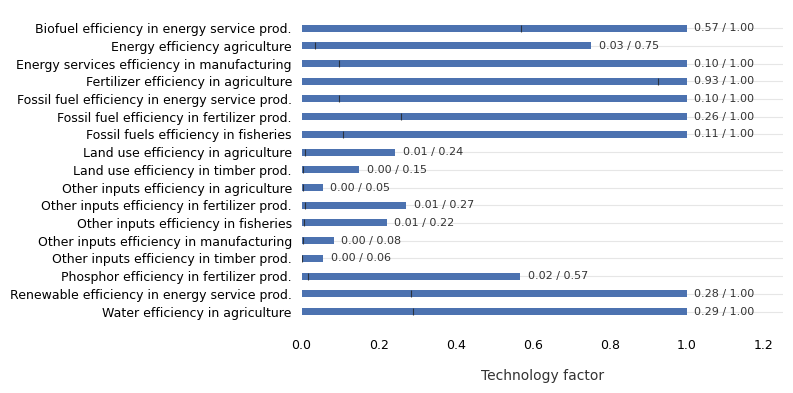

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------
# Matplotlib configuration (paper-friendly)
# --------------------------------------------------
plt.rcdefaults()
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.figsize": (8, 4),
})

# --------------------------------------------------
# Prepare DataFrame
# --------------------------------------------------
df = (
    pd.DataFrame.from_dict(
        {k[1]: v for k, v in tech_param_range.items() if v},
        orient="index"
    )
    .sort_index(ascending=False)
)

df.columns = ["space", "unused", "center"]

# --------------------------------------------------
# Create figure
# --------------------------------------------------
fig, ax = plt.subplots()

bar_color = "#4C72B0"
text_color = "#333333"
grid_color = "#E6E6E6"

bars = ax.barh(
    df.index,
    df["space"],
    height=0.4,
    color=bar_color,
    align="center",
)

# --------------------------------------------------
# Axis styling
# --------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.tick_params(left=False, bottom=False)
ax.set_axisbelow(True)

ax.yaxis.grid(True, color=grid_color, linewidth=0.8)
ax.xaxis.grid(False)

# --------------------------------------------------
# Text annotations (outside bars)
# --------------------------------------------------
offset = df["space"].max() * 0.02

for bar, center in zip(bars, df["center"]):
    width = bar.get_width()
    y_center = bar.get_y() + bar.get_height() / 2

    label = f"{center:.2f} / {width:.2f}"

    ax.text(
        width + offset,
        y_center,
        label,
        va="center",
        ha="left",
        fontsize=8,
        color=text_color,
        clip_on=False,
    )

# --------------------------------------------------
# Vertical center markers
# --------------------------------------------------
for bar, center in zip(bars, df["center"]):
    y_bottom = bar.get_y()
    y_top = y_bottom + bar.get_height()

    ax.vlines(
        x=center,
        ymin=y_bottom,
        ymax=y_top,
        colors="#222222",
        linewidth=0.8,
        alpha=0.8,
        zorder=3,
    )

# --------------------------------------------------
# Labels and limits
# --------------------------------------------------
ax.set_xlabel("Technology factor", labelpad=12, color=text_color)
ax.set_ylabel("")

xmax = df["space"].max()
ax.set_xlim(0, xmax * 1.25)

fig.tight_layout()

# --------------------------------------------------
# Save figure (publication-ready)
# --------------------------------------------------
fig.savefig("./figures/tech_factor_space.png", dpi=300)

plt.show()


# Food prices

In [ ]:
importlib.reload(model)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
param_list = list(params.df_typing_formatting.T.to_dict().values())
model_params = {row["keys"]: row["values"] for row in param_list}
sm = model.SolveModel(model_params)
prod_change_dict = sm.prod_change_dict
importlib.reload(pbc)

dft = pbc.compute_pb_tech_individual_with_food_prices()

In [20]:
dft.to_numpy()[:,[9,10]]

array([[-2.02742983e-01,  1.44775430e-01],
       [-5.29824759e-02,  3.78951597e-02],
       [-6.55863134e-02,  4.69591910e-02],
       [-1.87228371e-02,  1.33913127e-02],
       [-7.33267179e-01,  5.24461652e-01],
       [-5.05875714e-03,  3.70955309e-03],
       [-1.95619477e-02,  1.39778839e-02],
       [-4.09656086e-02,  2.92717540e-02],
       [ 3.96056982e-02, -2.81032173e-02],
       [-6.07457948e-02,  6.02181008e-02],
       [-4.10462697e-03,  4.01696724e-03],
       [-2.25057000e-02,  3.37383135e-02],
       [ 6.87725401e-02,  2.15212703e-01],
       [-5.74436144e-03,  4.13393913e-03],
       [-3.17709782e-02,  2.27144103e-02],
       [-1.39451807e-03,  3.63790982e-04],
       [ 2.42812094e-03, -3.62117766e-03]])

In [12]:
pbc.compute_pb_tech_individual()

,Aerosol effect,CO2 effect,Biodiv. incl. climate effect,Biogeochem. effect,Freshwater effect,Ocean acid. effect,Land-use effect,Ozone effect,Chem. effect
A_LA,0.0011,0.0411,0.0361,-0.0906,-0.0421,0.0411,-0.0095,1.0000,0.0000
A_EpsA,0.0003,0.0090,0.0118,0.0353,0.0185,0.0090,0.0210,1.0000,0.0000
A_P,0.0002,0.0066,-0.0068,-0.7402,0.0228,0.0066,0.0260,1.0000,0.0000
A_W,0.0001,0.0032,0.0042,0.0125,-0.3843,0.0032,0.0074,1.0000,0.0000
A_MA,0.0039,0.1242,0.1629,0.4880,0.2563,0.1242,0.2910,1.0000,0.0000
P_EP,-0.0002,-0.0075,0.0038,-0.7438,0.0015,-0.0075,0.0020,1.0000,-1.0000
P_Pho,0.0001,0.0046,0.0157,-0.4766,0.0069,0.0046,0.0078,1.0000,0.0000
P_MP,0.0003,0.0096,0.0328,0.4802,0.0144,0.0096,0.0163,1.0000,0.0000
Eps_AB,-0.0006,-0.0125,-0.0021,0.0256,0.0098,-0.0125,-0.0347,-1.0000,-1.0000
Eps_EEps,-0.0106,-0.1822,0.0065,0.0300,-0.0183,-0.1822,0.0240,0.0000,-1.0000


In [5]:
dft.to_csv('tech_change_with_food_prices.csv')

In [6]:
sm.prod_change_dict['A_LA'] = 1
df_carbontax_quantities, df_carbontax_prices = sm.gen_results(
    robust_check=False, biofuel_tax=0
)
df_carbontax_quantities
pb = sm.pb_effects(df_carbontax_quantities)
pb

,description,max value,min value,mean value,Aerosol effect,CO2 effect,Biodiv. incl. climate effect,Biogeochem. effect,Freshwater effect,Ocean acid. effect,Land-use effect,Ozone effect,Chem. effect
0,$L_A$ $\text{(land-share agriculture)}$,0.0074,0.0074,0.0074,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0
1,$L_T$ $\text{(land-share timber)}$,0.0173,0.0173,0.0173,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0
2,$L_U$ $\text{(land-share other)}$,-0.0095,-0.0095,-0.0095,0.0000,0.0012,0.0000,0.0000,0.0000,0.0012,-0.0095,0,0
3,$E$ $\text{(fossil-fuel extracted)}$,0.0239,0.0239,0.0239,0.0000,0.0022,0.0001,0.0000,0.0000,0.0022,0.0000,1,0
4,$E_{\mathcal{E}}$ $\text{(fossil-fuel use ener...,0.0253,0.0253,0.0253,0.0009,0.0149,0.0000,0.0000,0.0000,0.0149,0.0000,0,0
5,$E_P$ $\text{(fossil-fuel use fertilizer prod.)}$,-0.0504,-0.0504,-0.0504,-0.0000,-0.0007,0.0000,-0.0504,0.0000,-0.0007,0.0000,0,0
6,$E_F$ $\text{(fossil-fuel use fisheries)}$,-0.0711,-0.0711,-0.0711,-0.0000,-0.0002,0.0000,0.0000,0.0000,-0.0002,0.0000,0,0
7,$A\;\;$ $\text{(agriculture total production)}$,0.1630,0.1630,0.1630,0.0000,0.0225,0.0335,0.0000,0.0000,0.0225,0.0000,1,0
8,$A_B$ $\text{(agriculture prod. for biofuels)}$,0.4437,0.4437,0.4437,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,0
9,$A_F$ $\text{(agriculture prod. for food)}$,0.1519,0.1519,0.1519,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0


In [7]:
price_fisheries = df_carbontax_prices.at[3, "mean value"]
price_agric = df_carbontax_prices.at[0, "mean value"]
price_fisheries*model_params["GammaF_Fi"] + (1-model_params["GammaF_Fi"])*price_agric

-0.20274298290449272

In [8]:
model_params

{'sigma_U': [0.4, 0.6, 0.5],
 'sigma_F': [1.13, 1.33, 1.23],
 'sigma_nF': [1.5, 2.1, 1.8],
 'sigma_A': [1.1, 1.24, 1.14],
 'sigma_P': [0.05, 0.3, 0.2],
 'sigma_nLA': [0.25, 0.75, 0.5],
 'sigma_Eps': [1.5, 2.1, 1.8],
 'sigma_Fi': [0.1, 1, 0.2],
 'sigma_T': [0.1, 1, 0.2],
 'sigma_Y': [0.1, 1, 0.5],
 'Lambda_R': 0.37037037037037035,
 'Lambda_E': [0.8, 1.2, 1],
 'Lambda_W': 0.5586592178770949,
 'Lambda_Pho': 0.6666666666666666,
 'Lambda_M': [0, 2, 1],
 'Q_LA': 0.53,
 'Q_LT': 0.02,
 'Q_AB': 0.038,
 'Q_EpsA': 0.05,
 'Q_EP': 0.014,
 'Q_EFi': 0.004,
 'GammaU_F': 0.1235,
 'GammaF_Fi': 0.034,
 'GammanF_Y': 0.991,
 'GammanF_LU': 0.01711,
 'GammaA_LA': 0.192,
 'GammanLA_P': 0.0796,
 'GammanLA_W': 0.0239,
 'GammaP_EP': 0.1095,
 'GammaEps_AB': 0.0037,
 'GammaEps_EEps': 0.9433,
 'GammaFi_EFi': 0.228,
 'GammaT_LT': 0.3748,
 'GammaY_EpsY': 0.0638,
 'GammanLA_EpsA': 0.0412,
 'GammaP_Pho': 0.3127,
 'V_T': 0.05,
 'V_A': 0.05,
 'tau_E': 0.0}